<a href="https://colab.research.google.com/github/Ersaoktaviannn/eeg-creative-state-classifier/blob/dev/State_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mne pywavelets statsmodels seaborn

from google.colab import drive
import os
import re
import warnings
import numpy as np
import pandas as pd
import scipy.io
import pywt
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

import mne
from mne import create_info
from mne.io import RawArray
from mne.filter import notch_filter, filter_data
from mne.preprocessing import ICA

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DATASET_PATH = "/content/drive/MyDrive/Creativity-Dataset"
FILE_PATTERN = "Data_Creativity_Sub_{sid}.mat"

CHANNEL_NAMES = [
    'Fp1','Fp2','F3','F4','F7','F8',
    'C3','C4','T3','T4','T5','T6',
    'P3','P4','O1','O2'
]

SELECTED_CHANNELS_IDX = list(range(len(CHANNEL_NAMES)))

SFREQ_TARGET = 125
EPOCH_DURATION_SEC = 1.0

USE_ICA = True
NOTCH_FREQ = 50
BANDPASS_LOW = 1
BANDPASS_HIGH = 40

WAVELET = "db4"
DWT_LEVEL = 5

KNN_NEIGHBORS = [1,3,5,7,9,11,15,21]
RANDOM_STATE = 42

LABEL_MAP = {
    "IDE": 0,
    "IDG": 1,
    "IDR": 2,
    "RST1": 3,
    "RST2": 4,
}

LABEL_NAMES = ["IDE","IDG","IDR","RST1","RST2"]

In [3]:
def get_available_subject_ids():
    files = os.listdir(DATASET_PATH)
    return sorted([
        int(re.findall(r'\d+', f)[0])
        for f in files if f.endswith('.mat')
    ])


def load_eeg_mat(file_path):
    mat_data = scipy.io.loadmat(file_path)

    condition_data = {
        "IDE": [], "IDG": [], "IDR": [],
        "RST1": [], "RST2": []
    }

    for key, value in mat_data.items():
        if key.startswith("__"):
            continue
        if not isinstance(value, np.ndarray) or value.ndim != 2:
            continue

        data = value[SELECTED_CHANNELS_IDX, :]

        if "IDE" in key:
            condition_data["IDE"].append(data)
        elif "IDG" in key:
            condition_data["IDG"].append(data)
        elif "IDR" in key:
            condition_data["IDR"].append(data)
        elif "RST1" in key:
            condition_data["RST1"].append(data)
        elif "RST2" in key:
            condition_data["RST2"].append(data)

    for k in condition_data:
        if condition_data[k]:
            condition_data[k] = np.concatenate(condition_data[k], axis=1)
        else:
            condition_data[k] = None

    return condition_data

In [4]:
def apply_filter(eeg):
    eeg = notch_filter(eeg, SFREQ_TARGET, freqs=NOTCH_FREQ, verbose=False)
    eeg = filter_data(eeg, SFREQ_TARGET, BANDPASS_LOW, BANDPASS_HIGH, verbose=False)
    eeg = eeg - np.mean(eeg, axis=0)
    return eeg


def apply_ica(eeg):
    info = create_info(CHANNEL_NAMES, SFREQ_TARGET, ch_types="eeg")
    raw = RawArray(eeg, info, verbose=False)

    ica = ICA(n_components=min(len(CHANNEL_NAMES), 15), random_state=RANDOM_STATE)
    ica.fit(raw, verbose=False)

    cleaned = ica.apply(raw.copy(), verbose=False)
    return cleaned.get_data()


def preprocess(eeg):
    eeg = apply_filter(eeg)
    if USE_ICA:
        eeg = apply_ica(eeg)
    return eeg

In [5]:
def segment_epochs(eeg):
    samples = int(EPOCH_DURATION_SEC * SFREQ_TARGET)
    n_epochs = eeg.shape[1] // samples

    eeg = eeg[:, :n_epochs * samples]
    epochs = eeg.reshape(len(CHANNEL_NAMES), n_epochs, samples)
    epochs = np.transpose(epochs, (1,0,2))
    return epochs


def hjorth(x):
    var = np.var(x)
    dx = np.diff(x)
    ddx = np.diff(dx)

    mobility = np.sqrt(np.var(dx)/var) if var > 0 else 0
    complexity = np.sqrt(np.var(ddx)/np.var(dx))/mobility if mobility > 0 else 0

    return [var, mobility, complexity]


def extract_features(epoch):
    feat = []
    for ch in epoch:
        coeffs = pywt.wavedec(ch, WAVELET, level=DWT_LEVEL)
        feat.extend(hjorth(coeffs[0]))
        feat.extend(hjorth(coeffs[-1]))
    return np.array(feat)


def extract_all(epochs):
    return np.array([extract_features(e) for e in epochs])

In [6]:
def process_subject(sid):
    path = os.path.join(DATASET_PATH, FILE_PATTERN.format(sid=sid))
    cond_data = load_eeg_mat(path)

    features_dict = {}

    for cond, data in cond_data.items():
        if data is None:
            continue

        clean = preprocess(data)
        epochs = segment_epochs(clean)
        features = extract_all(epochs)

        features_dict[cond] = features

    return features_dict

In [7]:
def build_dataset(subjects):
    X, y, groups = [], [], []

    for sid in subjects:
        print(f"Processing {sid}...", end=" ")

        try:
            data = process_subject(sid)

            for cond, feat in data.items():
                X.append(feat)
                y.extend([LABEL_MAP[cond]] * len(feat))
                groups.extend([sid] * len(feat))

            print("OK")

        except Exception as e:
            print("FAILED:", e)

    return np.vstack(X), np.array(y), np.array(groups)

In [8]:
def evaluate(X, y, groups):
    logo = LeaveOneGroupOut()

    all_true, all_pred = [], []

    for train_idx, test_idx in logo.split(X, y, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier())
        ])

        grid = GridSearchCV(
            pipe,
            {"knn__n_neighbors": KNN_NEIGHBORS},
            cv=StratifiedKFold(3, shuffle=True),
            n_jobs=-1
        )

        grid.fit(X_train, y_train)
        pred = grid.predict(X_test)

        all_true.extend(y_test)
        all_pred.extend(pred)

    print(classification_report(all_true, all_pred, target_names=LABEL_NAMES))

    cm = confusion_matrix(all_true, all_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=LABEL_NAMES,
                yticklabels=LABEL_NAMES,
                cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Processing 1... OK
Processing 2... OK
Processing 3... OK
Processing 4... OK
Processing 5... OK
Processing 6... OK
Processing 7... OK
Processing 8... OK
Processing 9... OK
Processing 10... OK
Processing 11... OK
Processing 12... OK
Processing 13... OK
Processing 14... OK
Processing 15... OK
Processing 16... OK
Processing 17... OK
Processing 18... OK
Processing 19... OK
Processing 20... OK
Processing 21... OK
Processing 22... OK
Processing 23... OK
Processing 24... OK
Processing 25... OK
Processing 26... OK
Processing 27... OK
Processing 28... OK
Shape: (88880, 96)
              precision    recall  f1-score   support

         IDE       0.36      0.74      0.49     31176
         IDG       0.22      0.09      0.13     18160
         IDR       0.09      0.00      0.00      5536
        RST1       0.27      0.19      0.23     20216
        RST2       0.18      0.04      0.07     13792

    accuracy                           0.33     88880
   macro avg       0.23      0.21      0.18     88

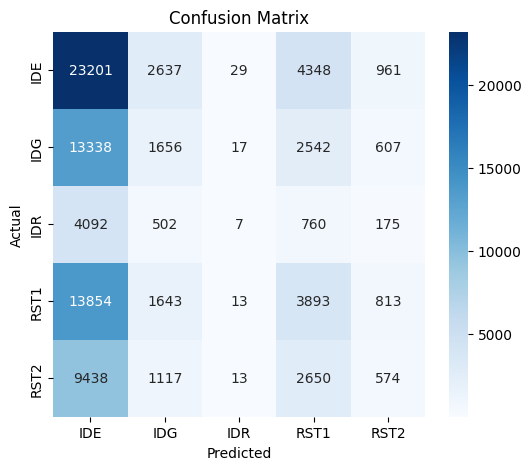

In [9]:
SUBJECTS = get_available_subject_ids()

X, y, groups = build_dataset(SUBJECTS)

print("Shape:", X.shape)

evaluate(X, y, groups)